# Sinapsa — Belgium 7-day weather API exercise

## Goal

Build one simple and reusable data pipeline:

**ODWB Belgian communes → coordinates → Open-Meteo → Pandas → chart**

For now we deliberately work with a **small sample of 5 communes**.

Later:
1. scale from 5 communes to all Belgian communes;
2. add Moldova administrative regions;
3. save the results;
4. connect the result to the Sinapsa website.

## Open sources

- Belgium administrative source: ODWB — Communes/Gemeente
- Weather source: Open-Meteo Forecast API
- Moldova later: BNS CUATM + geographic source for coordinates

### Rule for this notebook

Each major task appears **once**:
1. imports and settings;
2. get communes;
3. inspect one commune;
4. get weather;
5. collect all forecasts;
6. create Pandas table;
7. plot.


## 1. Imports and settings

This cell contains the libraries and the few settings we may want to change.

For now, if you want to test more or fewer communes, change only `N_COMMUNES`.


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply one visual theme for the complete notebook.
sns.set_theme(style="whitegrid")

# Start small while testing.
N_COMMUNES = 5

ODWB_URL = (
    "https://www.odwb.be/api/explore/v2.1/catalog/datasets/"
    "communes-gemeente-vintage-millesime-belgium/records"
)

OPEN_METEO_URL = "https://api.open-meteo.com/v1/forecast"


## 2. Get Belgian communes from ODWB

This cell has one purpose:

> Ask ODWB for a small list of communes.

We do **not** print the full geographic polygon (`geo_shape`) because it is extremely long and not needed for the weather exercise.


In [2]:
params = {
    "limit": N_COMMUNES
}

response = requests.get(
    ODWB_URL,
    params=params,
    timeout=20
)

# Stop immediately with a clear error if the HTTP request failed.
response.raise_for_status()

communes_data = response.json()
communes = communes_data["results"]

print("HTTP status:", response.status_code)
print("Total records available:", communes_data["total_count"])
print("Records received:", len(communes))


HTTP status: 200
Total records available: 4051
Records received: 5


## 3. Inspect the useful fields of one commune

One ODWB record contains many fields.

For this weather project we need mainly:

- commune name;
- commune code;
- latitude;
- longitude.

This inspection cell avoids printing the huge polygon contained in `geo_shape`.


In [3]:
first_commune = communes[0]

names = (
    first_commune.get("mun_name_fr")
    or first_commune.get("mun_name_nl")
    or first_commune.get("mun_name_de")
)

first_name = names[0]
first_code = first_commune["mun_code"][0]
first_latitude = first_commune["geo_point_2d"]["lat"]
first_longitude = first_commune["geo_point_2d"]["lon"]

print("Commune:", first_name)
print("Code:", first_code)
print("Latitude:", first_latitude)
print("Longitude:", first_longitude)


Commune: Jalhay
Code: 63038
Latitude: 50.530835382978985
Longitude: 5.966473841178134


## 4. Translate Open-Meteo weather codes

Open-Meteo returns numerical WMO weather codes.

We keep the numerical code in the data and also create a readable description for presentation.


In [4]:
weather_descriptions = {
    0: "Clear sky",
    1: "Mainly clear",
    2: "Partly cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Rime fog",
    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",
    56: "Light freezing drizzle",
    57: "Dense freezing drizzle",
    61: "Light rain",
    63: "Moderate rain",
    65: "Heavy rain",
    66: "Light freezing rain",
    67: "Heavy freezing rain",
    71: "Light snow",
    73: "Moderate snow",
    75: "Heavy snow",
    77: "Snow grains",
    80: "Light rain showers",
    81: "Moderate rain showers",
    82: "Heavy rain showers",
    85: "Light snow showers",
    86: "Heavy snow showers",
    95: "Thunderstorm",
    96: "Thunderstorm with light hail",
    99: "Thunderstorm with heavy hail",
}


## 5. Function: get the 7-day weather forecast

This is the central reusable function.

Input:

`commune name + code + latitude + longitude`

Output:

a list containing **7 dictionaries — one dictionary per forecast day**.


In [5]:
def get_weather(commune_name, commune_code, latitude, longitude):
    weather_params = {
        "latitude": latitude,
        "longitude": longitude,
        "daily": (
            "temperature_2m_max,"
            "temperature_2m_min,"
            "precipitation_sum,"
            "precipitation_probability_max,"
            "weather_code"
        ),
        "timezone": "auto",
        "forecast_days": 7,
    }

    weather_response = requests.get(
        OPEN_METEO_URL,
        params=weather_params,
        timeout=20,
    )

    weather_response.raise_for_status()
    weather_data = weather_response.json()

    daily = weather_data["daily"]

    forecast_records = []

    for i in range(len(daily["time"])):
        record = {
            "country": "Belgium",
            "commune_code": commune_code,
            "commune": commune_name,
            "latitude": latitude,
            "longitude": longitude,
            "date": daily["time"][i],
            "temp_min": daily["temperature_2m_min"][i],
            "temp_max": daily["temperature_2m_max"][i],
            "precipitation_mm": daily["precipitation_sum"][i],
            "precipitation_probability": daily[
                "precipitation_probability_max"
            ][i],
            "weather_code": daily["weather_code"][i],
        }

        forecast_records.append(record)

    return forecast_records


## 6. Test the function with one commune

Before processing several communes, test the reusable function once.

Expected result:

**7 forecast records**.


In [6]:
test_forecast = get_weather(
    first_name,
    first_code,
    first_latitude,
    first_longitude,
)

print("Forecast records:", len(test_forecast))
print(test_forecast[0])


Forecast records: 7
{'country': 'Belgium', 'commune_code': '63038', 'commune': 'Jalhay', 'latitude': 50.530835382978985, 'longitude': 5.966473841178134, 'date': '2026-08-20', 'temp_min': 13.6, 'temp_max': 19.6, 'precipitation_mm': 0.3, 'precipitation_probability': 78, 'weather_code': 51}


## 7. Collect weather for the sample of communes

Now the two APIs are connected:

**ODWB → coordinates → Open-Meteo**

The loop below processes every commune in our current sample.

With 5 communes × 7 days, the expected result is **35 rows**.


In [7]:
all_forecasts = []

for commune in communes:
    names = (
        commune.get("mun_name_fr")
        or commune.get("mun_name_nl")
        or commune.get("mun_name_de")
    )

    commune_name = names[0]
    commune_code = commune["mun_code"][0]
    latitude = commune["geo_point_2d"]["lat"]
    longitude = commune["geo_point_2d"]["lon"]

    commune_forecast = get_weather(
        commune_name,
        commune_code,
        latitude,
        longitude,
    )

    all_forecasts.extend(commune_forecast)

print("Communes processed:", len(communes))
print("Forecast records:", len(all_forecasts))
print("Expected records:", len(communes) * 7)


Communes processed: 5
Forecast records: 35
Expected records: 35


## 8. Convert the result to a Pandas DataFrame

The API data are now transformed from a list of dictionaries into a proper table.

We also:

- convert `date` from text to a real datetime;
- translate the numerical weather code;
- sort the table.


In [8]:
df_weather = pd.DataFrame(all_forecasts)

df_weather["date"] = pd.to_datetime(df_weather["date"])

df_weather["weather"] = (
    df_weather["weather_code"]
    .map(weather_descriptions)
    .fillna("Unknown")
)

df_weather = (
    df_weather
    .sort_values(["commune", "date"])
    .reset_index(drop=True)
)

print("Shape:", df_weather.shape)
print()
print(df_weather.dtypes)

df_weather


Shape: (35, 12)

country                                 str
commune_code                            str
commune                                 str
latitude                            float64
longitude                           float64
date                         datetime64[us]
temp_min                            float64
temp_max                            float64
precipitation_mm                    float64
precipitation_probability             int64
weather_code                          int64
weather                                 str
dtype: object


,country,commune_code,commune,latitude,longitude,date,temp_min,temp_max,precipitation_mm,precipitation_probability,weather_code,weather
0,Belgium,63038,Jalhay,50.530835,5.966474,2026-08-20,13.6,19.6,0.30,78,51,Light drizzle
1,Belgium,63038,Jalhay,50.530835,5.966474,2026-08-21,12.6,17.9,0.50,96,51,Light drizzle
2,Belgium,63038,Jalhay,50.530835,5.966474,2026-08-22,11.7,16.6,6.18,91,61,Light rain
3,Belgium,63038,Jalhay,50.530835,5.966474,2026-08-23,8.2,17.0,0.30,0,51,Light drizzle
4,Belgium,63038,Jalhay,50.530835,5.966474,2026-08-24,9.7,21.7,0.00,14,3,Overcast
5,Belgium,63038,Jalhay,50.530835,5.966474,2026-08-25,15.7,25.7,3.00,52,53,Moderate drizzle
6,Belgium,63038,Jalhay,50.530835,5.966474,2026-08-26,16.7,24.8,0.00,27,3,Overcast
7,Belgium,53046,Lens,50.570460,3.911483,2026-08-20,14.2,19.4,0.70,100,51,Light drizzle
8,Belgium,53046,Lens,50.570460,3.911483,2026-08-21,12.4,18.4,8.50,100,63,Moderate rain
9,Belgium,53046,Lens,50.570460,3.911483,2026-08-22,10.2,18.5,0.08,51,3,Overcast


## 9. Basic quality checks

Before plotting, verify that the table has the expected structure.

These checks become increasingly important when we later scale to all communes.


In [9]:
print("Number of communes:", df_weather["commune"].nunique())
print("Number of rows:", len(df_weather))
print("Missing values:")
print(df_weather.isna().sum())


Number of communes: 5
Number of rows: 35
Missing values:
country                      0
commune_code                 0
commune                      0
latitude                     0
longitude                    0
date                         0
temp_min                     0
temp_max                     0
precipitation_mm             0
precipitation_probability    0
weather_code                 0
weather                      0
dtype: int64


## 10. Function: plot one commune

The chart uses:

- minimum temperature: line;
- maximum temperature: line;
- precipitation: bars on a second Y-axis;
- weather description: annotation.

The plotting logic is stored in one function so it does not need to be copied several times.


In [10]:
def plot_weather(commune_name, data):
    data = data.sort_values("date")

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(
        data["date"],
        data["temp_min"],
        marker="o",
        label="Minimum temperature",
    )

    ax1.plot(
        data["date"],
        data["temp_max"],
        marker="o",
        label="Maximum temperature",
    )

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Temperature (°C)")
    ax1.set_title(f"7-day weather forecast — {commune_name}")

    for date, temp, weather in zip(
        data["date"],
        data["temp_max"],
        data["weather"],
    ):
        ax1.annotate(
            weather,
            (date, temp),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

    ax2 = ax1.twinx()

    ax2.bar(
        data["date"],
        data["precipitation_mm"],
        alpha=0.3,
        label="Precipitation",
    )

    ax2.set_ylabel("Precipitation (mm)")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    ax1.tick_params(
        axis="x",
        rotation=45,
    )

    plt.tight_layout()
    plt.show()


## 11. Test the chart with one commune

Do not generate hundreds of graphs.

For learning and correction, first select one commune and verify that the chart works.


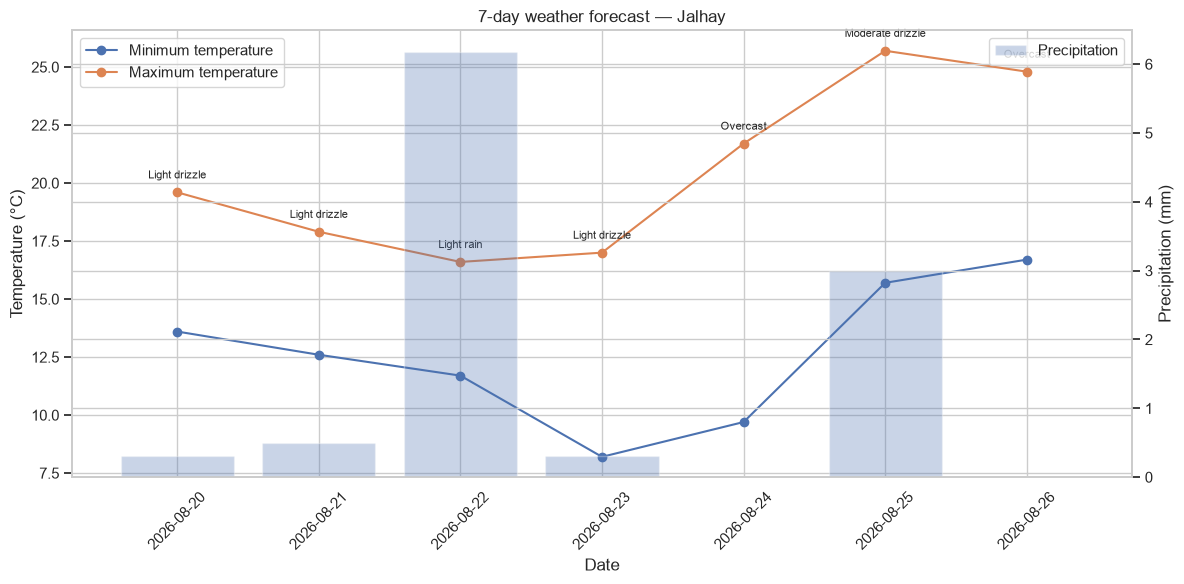

In [11]:
selected_commune = df_weather["commune"].iloc[0]

selected_data = df_weather[
    df_weather["commune"] == selected_commune
]

plot_weather(
    selected_commune,
    selected_data,
)


## 12. Optional: display the charts for the current small sample

This is acceptable while `N_COMMUNES = 5`.

Do **not** use this approach later for every Belgian commune.


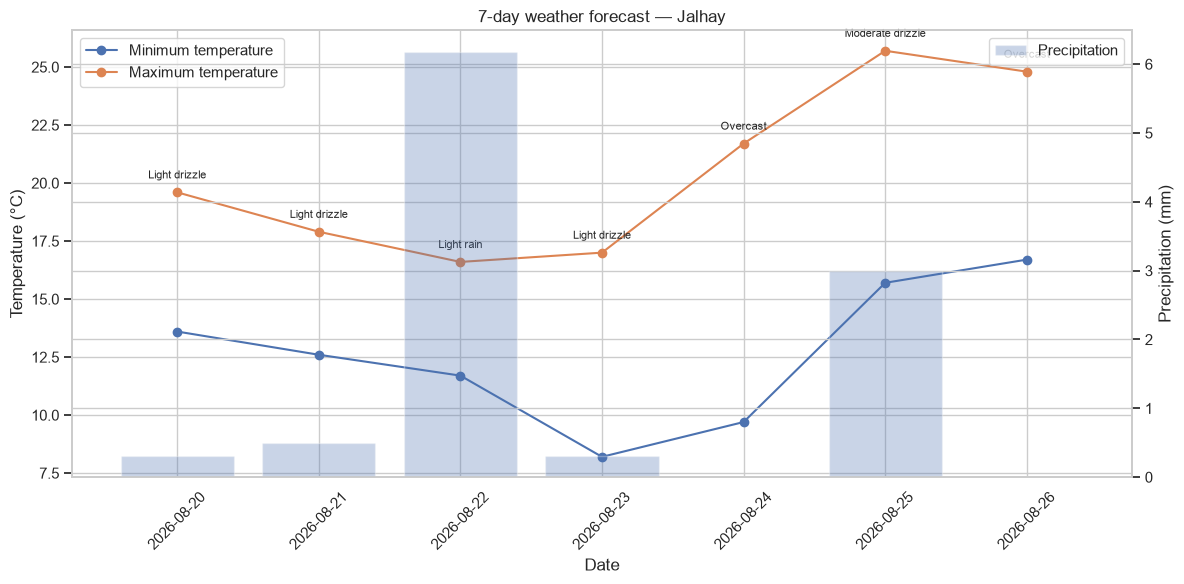

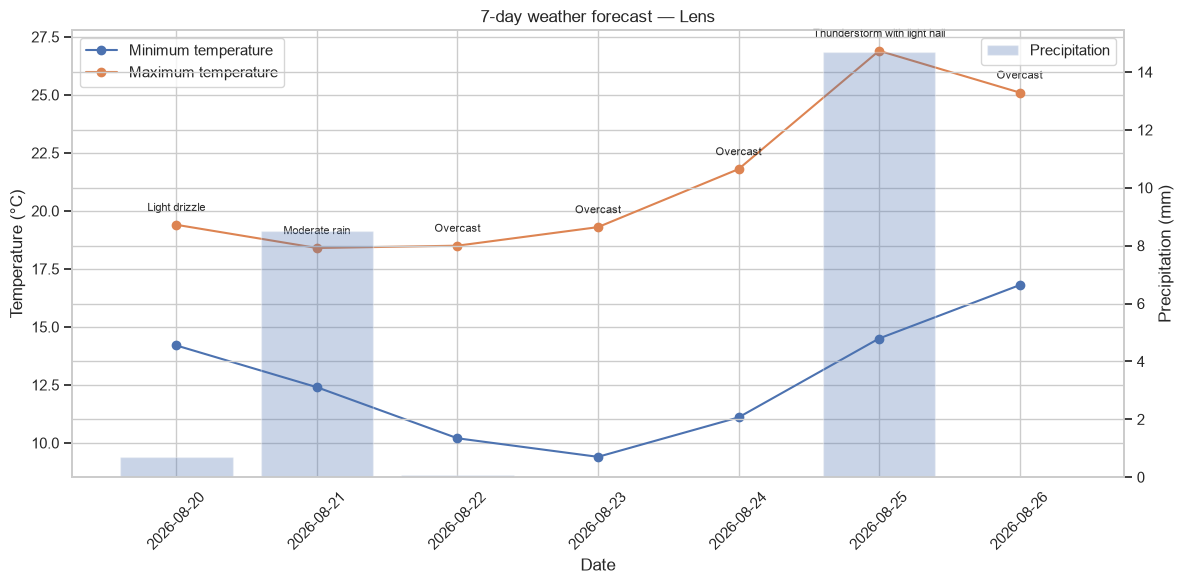

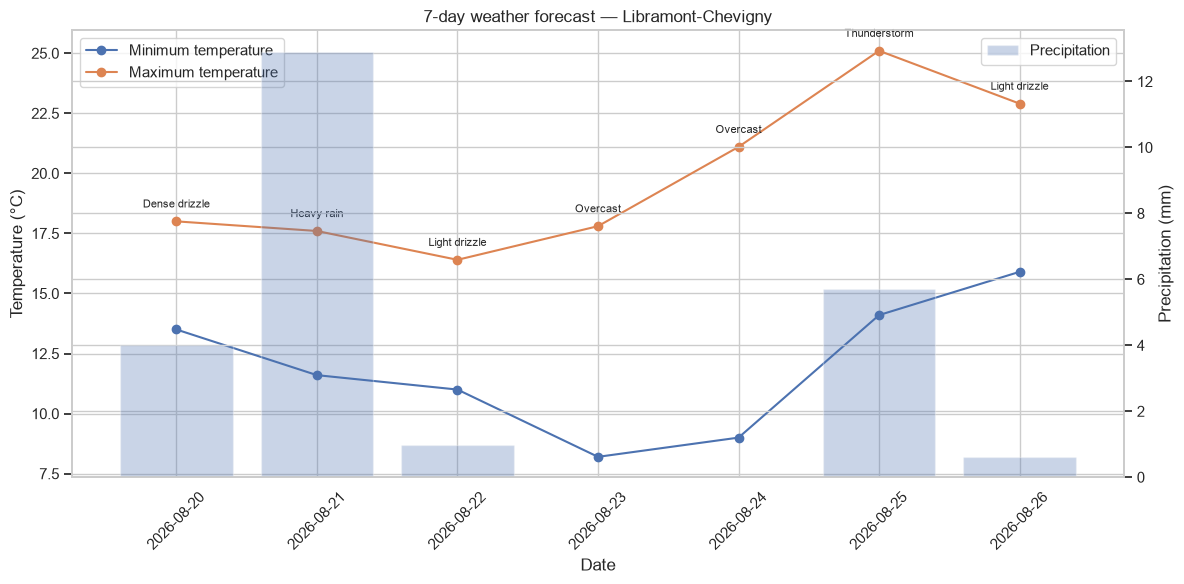

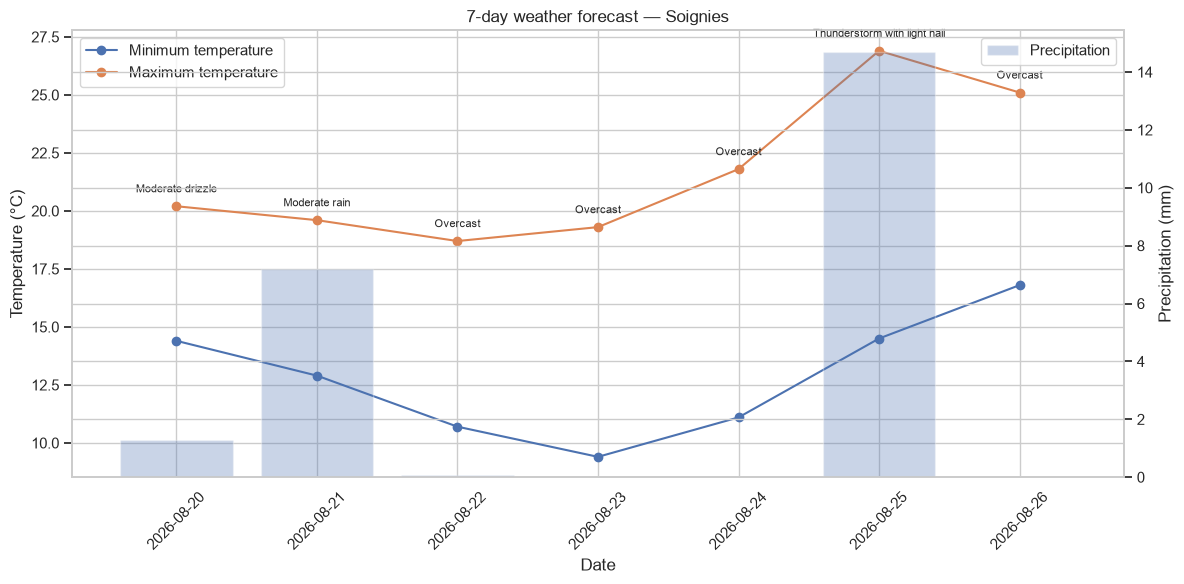

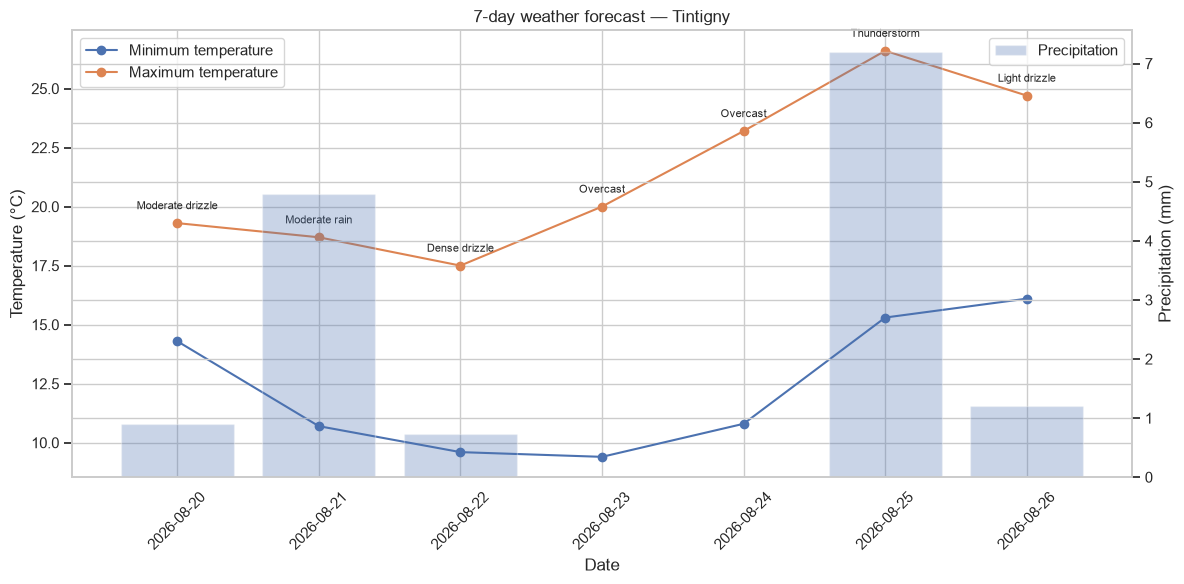

In [13]:
for commune_name, commune_data in df_weather.groupby("commune"):
    plot_weather(
        commune_name,
        commune_data,
    )


# Current pipeline

```text
ODWB API
   ↓
Belgian commune records
   ↓
name + code + coordinates
   ↓
get_weather()
   ↓
Open-Meteo
   ↓
7 daily records per commune
   ↓
Pandas DataFrame
   ↓
quality checks
   ↓
plot_weather()
   ↓
readable 7-day forecast
```

# Next development steps

Do these **one at a time**:

1. Confirm the clean notebook works with `N_COMMUNES = 5`.
2. Add pagination to retrieve all Belgian communes.
3. Save the resulting table to CSV.
4. Add Moldova administrative regions.
5. Standardise Belgium + Moldova into the same data model.
6. Later connect the output to the Sinapsa website.

Do not add all these steps at once.
